1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau}\frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

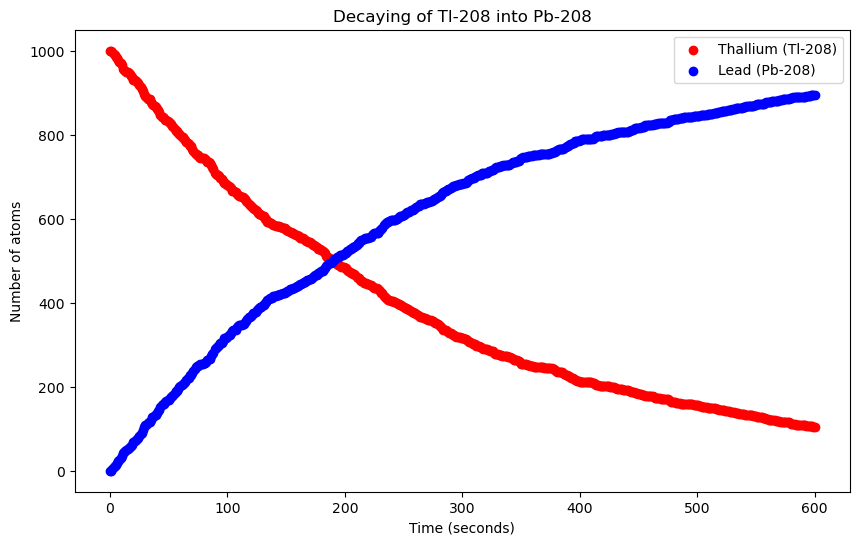

In [ ]:
# First part

import numpy as np
import matplotlib.pyplot as plt

n_Th = 1000
n_Pb = 0
tau = 3.052 * 60
np.random.seed(2404)       # Setting a seed for reproducible results

p_step = 1 - 2**(-1/tau)   # Probability of decaying in each step (constant)
time_steps = np.arange(601) 
Th_time = []
Pb_time = []

for t in time_steps:
    # Saving current number of atoms
    Th_time.append(n_Th)
    Pb_time.append(n_Pb)

    # Calculating how many atoms decayed
    decayed_atoms = 0
    for i in range(n_Th):
        if np.random.rand() < p_step: 
            decayed_atoms += 1
    
    # Updating number of atoms
    n_Th -= decayed_atoms
    n_Pb += decayed_atoms


plt.figure(figsize=(10,6))
plt.scatter(time_steps, Th_time, label="Thallium (Tl-208)", color='red')
plt.scatter(time_steps, Pb_time, label="Lead (Pb-208)", color='blue')

plt.xlabel("Time (seconds)")
plt.ylabel("Number of atoms")
plt.title("Decaying of Tl-208 into Pb-208")
plt.legend()
plt.show()

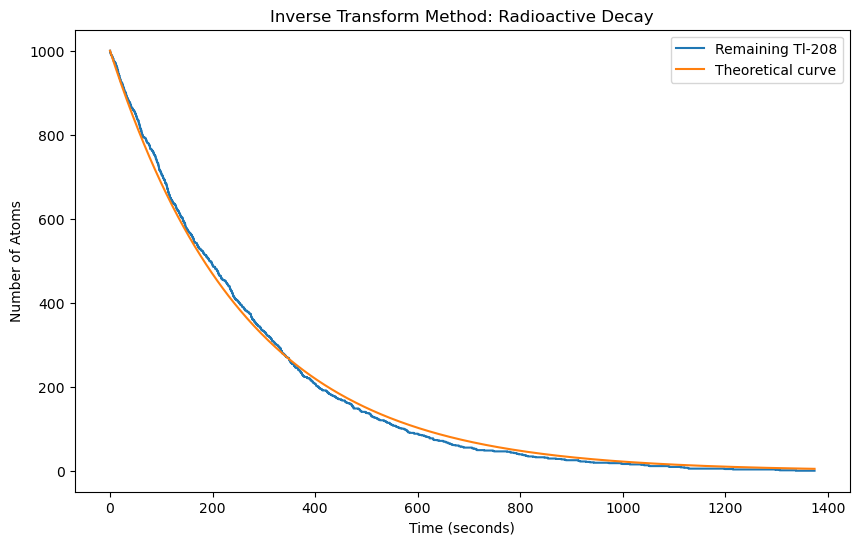

In [39]:
import numpy as np
import matplotlib.pyplot as plt

n_atoms = 1000
tau = 3.052 * 60
np.random.seed(2404)        # Fixed seed for reproducible results

# Inverse Transform Sampling
u = np.random.rand(n_atoms)
decay_times = -tau * np.log2(u)
decay_times_sorted = np.sort(decay_times)
atoms_remaining = np.arange(n_atoms, 0, -1)

# Visualization
plt.figure(figsize=(10, 6))
plt.step(decay_times_sorted, atoms_remaining, label="Remaining Tl-208")

# Theoretical Curve
t_range = np.linspace(0, max(decay_times_sorted), 500)
plt.plot(t_range, n_atoms * 2**(-t_range/tau), label="Theoretical curve")

plt.xlabel("Time (seconds)")
plt.ylabel("Number of Atoms")
plt.title("Inverse Transform Method: Radioactive Decay")
plt.legend()
plt.show()

2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

In [15]:
import numpy as np
from scipy.constants import epsilon_0, pi, hbar, electron_mass, elementary_charge as e

def theta(b: float, Z: int = 79, E: float = 7.7*10**6) -> float:
    tan = Z*e**2 / (2*pi*epsilon_0*b*(E*e))                         # Convert energy in Joule
    return 2 * np.arctan(tan)

a0 = (4 * pi * epsilon_0 * hbar**2) / (electron_mass * e**2)        # Bohr radius
n_particles = 1_000_000

# Generation of random impact parameters
sigma = a0 / 100
mu, cov = [0, 0], np.diag([sigma**2, sigma**2])
coords = np.random.multivariate_normal(mu, cov, n_particles)
b = np.sqrt(coords[:,0]**2 + coords[:,1]**2)


# Calculate and print the fraction of particles which backscattered
theta_array = theta(b)
backscatter = len(theta_array[theta_array > (pi/2)]) / len(theta_array)

print("Fraction of particles which bounced back: ", backscatter*100, "%")


Fraction of particles which bounced back:  0.1559 %


3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

In [33]:
import numpy as np
from scipy.integrate import quad

def f(x: float) -> float:
    return np.sin(1 / (x*(2-x)))**2

# Real value of the integral
integral = quad(func=f, a=0, b=2)

# Hit/miss method
N = 1_000_000
count = 0
for i in range(N):
    x = 2*np.random.random()
    y = np.random.random()
    if y < f(x): count += 1

integral_hitmiss = 2 * count / N
error_hitmiss = np.abs((integral_hitmiss - integral[0]) / integral[0]) 
print(f"The result of the integral with hit/miss method is: {integral_hitmiss}")
print(f"The error is: {(error_hitmiss * 100):.4f}%")

# Mean value
x = np.linspace(1e-10, 2, 1_000_000, endpoint=False)        # Avoid 0 and 2
y = f(x)
integral_meanvalue = 2 / N * np.sum(y)
error_meanvalue = 2 * np.sqrt(np.var(y)/N)

print(f"The result of the integral with hit/miss method is: {integral_meanvalue}")
print(f"The error is: {(error_meanvalue * 100):.4f}%")


/tmp/ipykernel_3734/2535692233.py:8: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral = quad(func=f, a=0, b=2)


The result of the integral with hit/miss method is: 1.45197
The error is: 0.0194%
The result of the integral with hit/miss method is: 1.451424664749077
The error is: 0.0527%


4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere



In [9]:
import numpy as np

N = 10_000_000

# Area of a circle with mean value method
coords_2D = np.random.uniform(-1, 1, (N, 2))
distance_2D = np.sum(coords_2D**2, axis=1)
inside_circle = distance_2D <= 1
area_circle = 4 / N * np.sum(inside_circle)
print("The area of a circle of unit radius is: ", area_circle)


# Generalization for a 10D sphere
coords_10D = np.random.uniform(-1, 1, (N, 10))
distance_10D = np.sum(coords_10D**2, axis=1)
inside_sphere = distance_10D <= 1
area_sphere = (2**10) / N * np.sum(inside_sphere)
print("The volume of a 10D sphere of unit radius is: ", area_sphere)



The area of a circle of unit radius is:  3.1420695999999997
The volume of a 10D sphere of unit radius is:  2.5303039999999997


5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [ ]:
import numpy as np
from scipy.integrate import quad

def f(x: float) -> float:
    return x**(-1/2) / (np.exp(x)+1)

def w(x: float) -> float:
    return 1/np.sqrt(x)

def inv_w(y: float) -> float:
    return (y/2)**2


N = 10_000
samples = np.random.uniform(0, 2, N)       # We generate samples between 0 and 2 (area of w(x))
x = inv_w(samples)
int_wx, _ = quad(func=w, a=0, b=1)         
I = 1/N * np.sum(f(x)/w(x)) * int_wx

print("The integral is: ", I)


The integral is:  0.8398992489602775
